# Figure S3 — Secondary structure across media, MIC by structural class, and sequence novelty

**Panels.**
- A, B, C: Stacked-bar CD/BeStSel composition for the 95 de novo peptides in H₂O, MeOH/H₂O, and TFE/H₂O (sorted by SDS helicity to match Figure 4B).
- D: MIC₅₀ by structural class (helical / β-rich / disordered), with pairwise Mann-Whitney significance brackets.
- E: Sequence novelty (max identity to training set) vs MIC₅₀, colored by structural class, Spearman correlation reported; leads Ω-DP-19 and Ω-DP-52 annotated.

**Inputs.** `bestsel.csv`, `omegamp_reference_table.csv`, `mic.csv`, `denovo_training_identity.csv` (precomputed maximum length-matched gapless identity of each de novo peptide to the training AMP set).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 7, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6,
    'axes.linewidth': 0.5, 'axes.edgecolor': '#888888',
    'xtick.color': '#555555', 'ytick.color': '#555555',
    'axes.labelcolor': '#333333', 'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.dpi': 300, 'savefig.dpi': 600,
    'xtick.major.width': 0.5, 'ytick.major.width': 0.5,
    'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
})

DATA = '/home/pszymczak/code/omegamp-dashboard/data/'
OUT  = '/home/pszymczak/code/omegamp-dashboard/figures/'

In [2]:
# Color palettes — kept consistent with Figure 4B (SS_COLORS) and the SS_SCATTER mapping used in D, E
SS_COLORS  = {'Helix': '#5B8FB9', 'Beta': '#B6846C', 'Turn': '#7EB77F', 'Other': '#D1D1D1'}
SS_SCATTER = {'Helical': '#5B8FB9', 'β-rich': '#B6846C', 'Disordered': '#D1D1D1'}

In [3]:
# Load inputs
ref     = pd.read_csv(DATA + 'omegamp_reference_table.csv')
mic     = pd.read_csv(DATA + 'mic.csv')
_dc = lambda v: float(str(v).lstrip('>')) if pd.notna(v) else float('nan')
for _c in mic.columns[1:]:
    mic[_c] = mic[_c].apply(_dc)


bestsel = pd.read_csv(DATA + 'bestsel.csv')
novelty = pd.read_csv(DATA + 'denovo_training_identity.csv')

for d in [ref, mic, bestsel, novelty]:
    d['short_name'] = d['short_name'].str.strip()

# MIC50 across full panel (NaN -> 128, clip at 128 per manuscript convention)
mic_strains = [c for c in mic.columns if c != 'short_name']
mic_vals = mic[mic_strains].astype(float).fillna(128).clip(upper=128)
mic['mic50'] = mic_vals.median(axis=1)

# Secondary structure class (SDS): helical / β-rich / disordered
bs = bestsel.merge(ref[['short_name', 'category']], on='short_name')
bs_dn = bs[bs['category'] == 'de_novo'].copy()
bs_dn['helix_SDS'] = bs_dn['fH_SDS_H2O']
bs_dn['beta_SDS'] = bs_dn['f_beta_anti_SDS_H2O'] + bs_dn['f_beta_par_SDS_H2O']

def classify(row):
    if row['helix_SDS'] > 50: return 'Helical'
    elif row['beta_SDS']  > 20: return 'β-rich'
    else: return 'Disordered'

bs_dn['ss_class'] = bs_dn.apply(classify, axis=1)
bs_dn_sorted = bs_dn.sort_values('fH_SDS_H2O', ascending=False).reset_index(drop=True)

# Scatter dataframe for D and E
scatter_df = (
    bs_dn[['short_name', 'ss_class']]
    .merge(mic[['short_name', 'mic50']], on='short_name', how='left')
    .merge(novelty[['short_name', 'best_id_lenmatched']], on='short_name', how='left')
)
scatter_df['identity_pct'] = scatter_df['best_id_lenmatched'] * 100
scatter_df['log2_mic50']  = np.log2(scatter_df['mic50'].clip(lower=0.5))

print(f'De novo peptides: {len(bs_dn)}')
print(f'  Helical:    {(bs_dn.ss_class=="Helical").sum()}')
print(f'  β-rich:     {(bs_dn.ss_class=="β-rich").sum()}')
print(f'  Disordered: {(bs_dn.ss_class=="Disordered").sum()}')



De novo peptides: 95
  Helical:    50
  β-rich:     18
  Disordered: 27


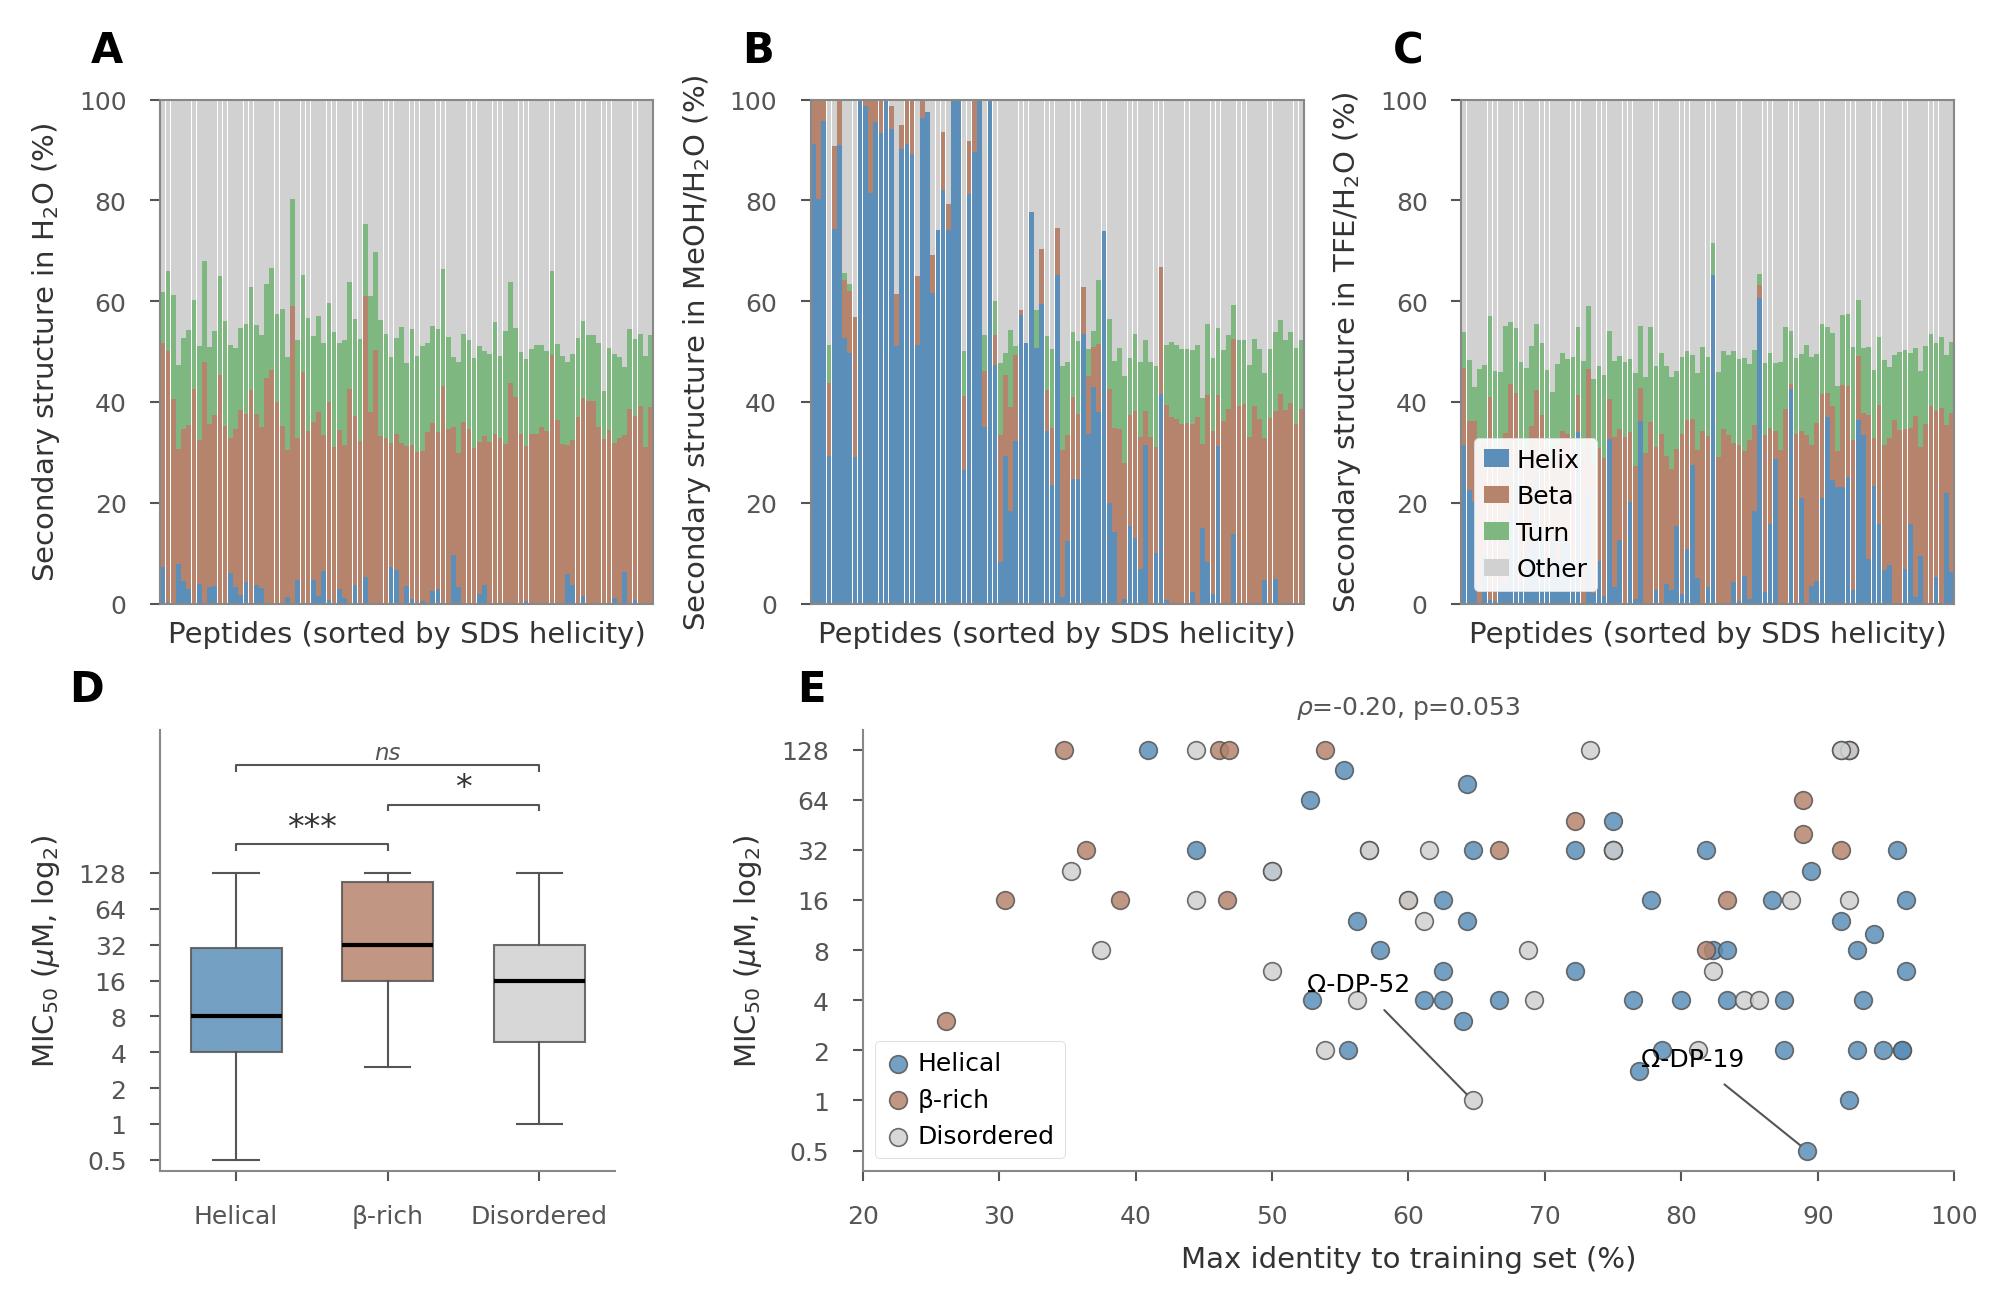

Saved figureS3_denovo


In [4]:
# === Figure assembly ===
fig = plt.figure(figsize=(6.5, 4.2), dpi=300)
gs_top = gridspec.GridSpec(1, 3, figure=fig, left=0.06, right=0.98, top=0.95, bottom=0.55, wspace=0.32)
gs_bot = gridspec.GridSpec(1, 2, figure=fig, left=0.06, right=0.98, top=0.45, bottom=0.10, wspace=0.32, width_ratios=[1, 2.4])
L = dict(fontsize=10, fontweight='bold', va='top', ha='left')

media = [
    ('H$_2$O',       'fH_H2O',      'f_beta_anti_H2O',      'f_beta_par_H2O',      'fturn_H2O',      'fothers_H2O',      'A'),
    ('MeOH/H$_2$O',  'fH_MeOH_H2O', 'f_beta_anti_MeOH_H2O', 'f_beta_par_MeOH_H2O', 'fturn_MeOH_H2O', 'fothers_MeOH_H2O', 'B'),
    ('TFE/H$_2$O',   'fH_TFE_H2O',  'f_beta_anti_TFE_H2O',  'f_beta_par_TFE_H2O',  'fturn_TFE_H2O',  'fothers_TFE_H2O',  'C'),
]

# A, B, C — cross-medium stacked bars (sorted by SDS helicity)
for col_i, (medium_label, h_col, ba_col, bp_col, t_col, o_col, letter) in enumerate(media):
    ax = fig.add_subplot(gs_top[col_i])
    ax.text(-0.14, 1.14, letter, transform=ax.transAxes, **L)
    df = bs_dn_sorted
    x = np.arange(len(df))
    ax.bar(x, df[h_col], width=0.9, color=SS_COLORS['Helix'], label='Helix')
    bottom = df[h_col].values.copy()
    beta = (df[ba_col] + df[bp_col]).values
    ax.bar(x, beta, bottom=bottom, width=0.9, color=SS_COLORS['Beta'], label='Beta')
    bottom = bottom + beta
    ax.bar(x, df[t_col], width=0.9, bottom=bottom, color=SS_COLORS['Turn'], label='Turn')
    bottom = bottom + df[t_col].values
    ax.bar(x, df[o_col], width=0.9, bottom=bottom, color=SS_COLORS['Other'], label='Other')
    ax.set_ylabel(f'Secondary structure in {medium_label} (%)')
    ax.set_xlabel('Peptides (sorted by SDS helicity)')
    ax.set_xlim(-0.5, len(df) - 0.5)
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    if col_i == 2:
        ax.legend(fontsize=6, loc='lower left', frameon=True, framealpha=0.9,
                  edgecolor='#ddd', handlelength=1, handletextpad=0.3)

# D — MIC50 by structural class with pairwise Mann-Whitney stars
ax_d = fig.add_subplot(gs_bot[0])
ax_d.text(-0.20, 1.14, 'D', transform=ax_d.transAxes, **L)

box_data, labels_d, colors_d = [], [], []
for cls in ['Helical', 'β-rich', 'Disordered']:
    sub = scatter_df[scatter_df['ss_class'] == cls]['log2_mic50'].dropna().values
    box_data.append(sub); labels_d.append(cls); colors_d.append(SS_SCATTER[cls])

bp = ax_d.boxplot(box_data, patch_artist=True, widths=0.6,
                  medianprops=dict(color='black', linewidth=1.0),
                  boxprops=dict(linewidth=0.5, edgecolor='#555'),
                  whiskerprops=dict(linewidth=0.5, color='#555'),
                  capprops=dict(linewidth=0.5, color='#555'),
                  flierprops=dict(marker='o', markersize=2.5,
                                  markerfacecolor='#888', markeredgecolor='none', alpha=0.6))
for patch, color in zip(bp['boxes'], colors_d):
    patch.set_facecolor(color); patch.set_alpha(0.85)

def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

pairs = [(0, 1, 'Helical', 'β-rich'),
         (1, 2, 'β-rich', 'Disordered'),
         (0, 2, 'Helical', 'Disordered')]
y_top = 7.5
heights = [y_top + 0.3, y_top + 1.4, y_top + 2.5]

for (i, j, na, nb), h in zip(pairs, heights):
    a = scatter_df[scatter_df['ss_class'] == na]['log2_mic50'].dropna().values
    b = scatter_df[scatter_df['ss_class'] == nb]['log2_mic50'].dropna().values
    _, pv = stats.mannwhitneyu(a, b, alternative='two-sided')
    x1, x2 = i + 1, j + 1
    ax_d.plot([x1, x1, x2, x2], [h - 0.15, h, h, h - 0.15], color='#555', lw=0.5)
    label = stars(pv)
    if label == 'ns':
        ax_d.text((x1 + x2) / 2, h + 0.05, label, ha='center', va='bottom',
                  fontsize=5.5, color='#555', fontstyle='italic')
    else:
        ax_d.text((x1 + x2) / 2, h + 0.02, label, ha='center', va='bottom',
                  fontsize=8, color='#333')

lo_y = int(np.floor(scatter_df['log2_mic50'].min()))
hi_y = int(np.ceil(scatter_df['log2_mic50'].max()))
yticks = list(range(lo_y, hi_y + 1))

ax_d.set_xticks([1, 2, 3])
ax_d.set_xticklabels(labels_d, fontsize=6)
ax_d.set_ylabel('MIC$_{50}$ ($\\mu$M, log$_2$)')
ax_d.set_yticks(yticks)
ax_d.set_yticklabels([str(int(2**t)) if t >= 0 else f'{2**t:.1f}' for t in yticks])
ax_d.set_ylim(lo_y - 0.3, y_top + 3.5)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# E — sequence novelty vs MIC50, colored by SS class; leads annotated
ax_e = fig.add_subplot(gs_bot[1])
ax_e.text(-0.06, 1.14, 'E', transform=ax_e.transAxes, **L)

for cls, color in SS_SCATTER.items():
    sub = scatter_df[scatter_df['ss_class'] == cls].dropna(subset=['identity_pct', 'log2_mic50'])
    ax_e.scatter(sub['identity_pct'], sub['log2_mic50'], s=18, c=color,
                 edgecolors='#555', linewidths=0.4, alpha=0.85, label=cls, zorder=3)

valid = scatter_df.dropna(subset=['identity_pct', 'log2_mic50'])
rho, p_s = stats.spearmanr(valid['identity_pct'], valid['log2_mic50'])
p_str = 'p<0.001' if p_s < 0.001 else f'p={p_s:.3f}'
ax_e.text(0.5, 1.02, f'$\\rho$={rho:.2f}, {p_str}', transform=ax_e.transAxes,
          fontsize=6, ha='center', va='bottom', color='#555', clip_on=False)

LEADS = {'Ω-DP-19': (-15, 22), 'Ω-DP-52': (-15, 28)}
for lead, off in LEADS.items():
    row = scatter_df[scatter_df['short_name'] == lead]
    if len(row):
        x, y = row.iloc[0]['identity_pct'], row.iloc[0]['log2_mic50']
        ax_e.annotate(lead, (x, y), xytext=off, textcoords='offset points',
                      fontsize=6, ha='right', va='center', color='black',
                      arrowprops=dict(arrowstyle='-', color='#555', lw=0.5), zorder=10)

ax_e.set_xlabel('Max identity to training set (%)')
ax_e.set_ylabel('MIC$_{50}$ ($\\mu$M, log$_2$)')
ax_e.set_xlim(20, 100)
ax_e.set_yticks(yticks)
ax_e.set_yticklabels([str(int(2**t)) if t >= 0 else f'{2**t:.1f}' for t in yticks])
ax_e.legend(fontsize=6, loc='lower left', frameon=True, framealpha=0.9,
            edgecolor='#ddd', handlelength=1, handletextpad=0.3)
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)

plt.savefig(OUT + 'figureS3_denovo.pdf', bbox_inches='tight')
plt.savefig(OUT + 'figureS3_denovo.svg', bbox_inches='tight')
plt.savefig(OUT + 'figureS3_denovo.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved figureS3_denovo')